In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
img_width,img_height=224,224
train_dir='C:\\Users\\HP\\Documents\\fruits\\train'
test_dir='C:\\Users\\HP\\Documents\\fruits\\test'
calories_file="C:\\Users\\HP\\Documents\\calories.xlsx"

In [5]:
train_datagen=keras.preprocessing.image.ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
train_generator=train_datagen.flow_from_directory(train_dir,target_size=(img_width,img_height),batch_size=32,class_mode='categorical')

Found 168 images belonging to 3 classes.


In [7]:
test_datagen=keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_generator=test_datagen.flow_from_directory(test_dir,target_size=(img_width,img_height),batch_size=32,class_mode='categorical')

Found 168 images belonging to 3 classes.


In [9]:
calories_data=pd.read_excel(calories_file)

In [11]:
model=keras.Sequential([keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_width,img_height,3)),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Conv2D(64,(3,3),activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Conv2D(128,(3,3),activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Flatten(),
                        keras.layers.Dense(128,activation='relu'),
                        keras.layers.Dense(len(train_generator.class_indices),activation='softmax')])
                                            

C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_generator,epochs=10,validation_data=test_generator)

C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 7s/step - accuracy: 0.2712 - loss: 5.5585 - val_accuracy: 0.4702 - val_loss: 1.0278
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.4855 - loss: 0.9735 - val_accuracy: 0.6012 - val_loss: 0.8189
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5635 - loss: 0.9322 - val_accuracy: 0.6964 - val_loss: 0.6918
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7106 - loss: 0.6497 - val_accuracy: 0.6012 - val_loss: 0.7032
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.6840 - loss: 0.6155 - val_accuracy: 0.7262 - val_loss: 0.7020
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7064 - loss: 0.5386 - val_accuracy: 0.6667 - val_loss: 0.6617
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7496 - loss: 0.4906 - val_accuracy: 0.7321 - val_loss: 0.6626
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8255 - loss: 0.4181 - val_accuracy: 0.7083 - val_loss: 0.6520
Epoch 9/

In [ ]:
plt.plot(history.history['accuracy'],
         label='Training Accuracy'),
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.legend()
plt.show()
         

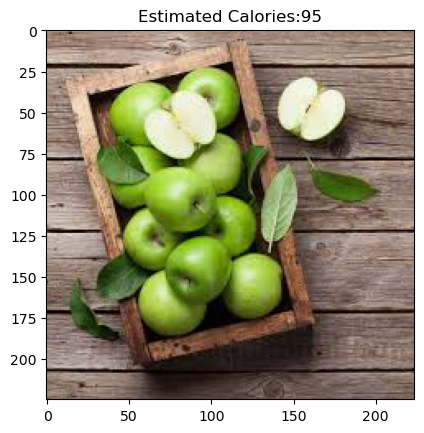

In [1]:
import matplotlib.pyplot as plt
def predict_food_item ():
 image_path='C:\\Users\\HP\\Documents\\fruits\\test\\Apple\\img_p2_32.jpeg'
img=plt.imread('C:\\Users\\HP\\Documents\\fruits\\test\\Apple\\img_p2_32.jpeg')
estimated_calories=95
plt.imshow(img)
plt.title(f'Estimated Calories:{estimated_calories}')
plt.show()
